In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------data preprocessing------------
df=pd.read_csv("Network.csv")
df.info()    #to get datastructure information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Timestamp            2910 non-null   object 
 1   Source_IP            2850 non-null   object 
 2   Destination_IP       3000 non-null   object 
 3   Source_Port          3000 non-null   int64  
 4   Destination_Port     3000 non-null   int64  
 5   Protocol             3000 non-null   object 
 6   Packet_Size          2760 non-null   float64
 7   Connection_Duration  2820 non-null   float64
 8   Packets_Per_Second   2760 non-null   float64
 9   Error_Rate           2820 non-null   float64
 10  Login_Attempts       3000 non-null   int64  
 11  Bytes_Sent           2760 non-null   float64
 12  Bytes_Received       2760 non-null   float64
 13  Traffic_Flag         3000 non-null   object 
 14  MAC_Address          2850 non-null   object 
 15  Label                3000 non-null   i

In [68]:
df.describe()   #to get statistical information

,Source_Port,Destination_Port,Packet_Size,Connection_Duration,Packets_Per_Second,Error_Rate,Login_Attempts,Bytes_Sent,Bytes_Received,Label
count,3000.000000,3000.000000,2760.000000,2820.000000,2760.000000,2820.000000,3000.000000,2760.000000,2760.000000,3000.000000
mean,33207.699333,1405.190667,1021.607971,402.711702,2980.267754,0.500984,12.086000,30472.977536,35534.315942,0.371000
std,18724.665241,2928.193129,569.840459,232.806543,1747.642955,0.289940,7.213826,17161.569435,20096.278263,0.483153
min,1028.000000,21.000000,40.000000,1.000000,1.000000,0.000575,0.000000,160.000000,152.000000,0.000000
25%,17147.000000,22.000000,544.750000,200.000000,1423.000000,0.252721,6.000000,15998.500000,17995.500000,0.000000
50%,32645.500000,53.000000,1006.000000,400.000000,2971.000000,0.496149,12.000000,30472.500000,36347.000000,0.000000
75%,49354.250000,443.000000,1521.000000,607.500000,4508.000000,0.753080,18.000000,45421.750000,52677.500000,1.000000
max,65530.000000,8080.000000,1999.000000,799.000000,5996.000000,0.999897,24.000000,59994.000000,69986.000000,1.000000


In [69]:
df.isnull().sum()  # to check null values in each column

Timestamp               90
Source_IP              150
Destination_IP           0
Source_Port              0
Destination_Port         0
Protocol                 0
Packet_Size            240
Connection_Duration    180
Packets_Per_Second     240
Error_Rate             180
Login_Attempts           0
Bytes_Sent             240
Bytes_Received         240
Traffic_Flag             0
MAC_Address            150
Label                    0
dtype: int64

In [70]:
# handle null values in timestamp column
df['Timestamp'] = df['Timestamp'].bfill().ffill()
#handle null values in Source IP and Mac Address
df['Source_IP']=df['Source_IP'].fillna("Unknown")
df['MAC_Address']=df['MAC_Address'].fillna("Unknown")
#handling null values in numerical datatype columns
col=['Packet_Size','Connection_Duration','Error_Rate','Packets_Per_Second','Bytes_Sent','Bytes_Received']
for c in col:
    df[c]=df[c].fillna(df[c].median())
df.isnull().sum()   #null values handled successfully

Timestamp              0
Source_IP              0
Destination_IP         0
Source_Port            0
Destination_Port       0
Protocol               0
Packet_Size            0
Connection_Duration    0
Packets_Per_Second     0
Error_Rate             0
Login_Attempts         0
Bytes_Sent             0
Bytes_Received         0
Traffic_Flag           0
MAC_Address            0
Label                  0
dtype: int64

In [71]:
#converting timestamp datatype
df['Timestamp']=pd.to_datetime(df['Timestamp'])
# Extract features
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month
# Remove original column
df.drop('Timestamp', axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Source_IP            3000 non-null   object 
 1   Destination_IP       3000 non-null   object 
 2   Source_Port          3000 non-null   int64  
 3   Destination_Port     3000 non-null   int64  
 4   Protocol             3000 non-null   object 
 5   Packet_Size          3000 non-null   float64
 6   Connection_Duration  3000 non-null   float64
 7   Packets_Per_Second   3000 non-null   float64
 8   Error_Rate           3000 non-null   float64
 9   Login_Attempts       3000 non-null   int64  
 10  Bytes_Sent           3000 non-null   float64
 11  Bytes_Received       3000 non-null   float64
 12  Traffic_Flag         3000 non-null   object 
 13  MAC_Address          3000 non-null   object 
 14  Label                3000 non-null   int64  
 15  Hour                 3000 non-null   i

In [72]:
#encoding categorical features
from sklearn.preprocessing import LabelEncoder
le1=LabelEncoder()
df['Protocol']=le1.fit_transform(df['Protocol'])    #encoding protocol column 


In [73]:
le2=LabelEncoder()
df['Traffic_Flag']=le2.fit_transform(df['Traffic_Flag'])  #encoding traffic_flag column 


In [74]:
#drop IP Address and MAC Address column as they do not contribute further in our Model training
df.drop(['Source_IP','Destination_IP','MAC_Address'], axis=1, inplace=True)  
print(df)

      Source_Port  Destination_Port  Protocol  Packet_Size  \
0           13552              8080         2       1006.0   
1           25373                22         2       1006.0   
2            3336                53         1       1324.0   
3            3114              8080         2       1865.0   
4           56727               443         1        584.0   
...           ...               ...       ...          ...   
2995        26775              8080         2       1692.0   
2996        63893                53         0        311.0   
2997        54729               443         2       1448.0   
2998        50458                21         0       1238.0   
2999        15850               443         1        353.0   

      Connection_Duration  Packets_Per_Second  Error_Rate  Login_Attempts  \
0                   334.0              2971.0    0.342323               3   
1                   687.0              2971.0    0.632884              15   
2                   559.

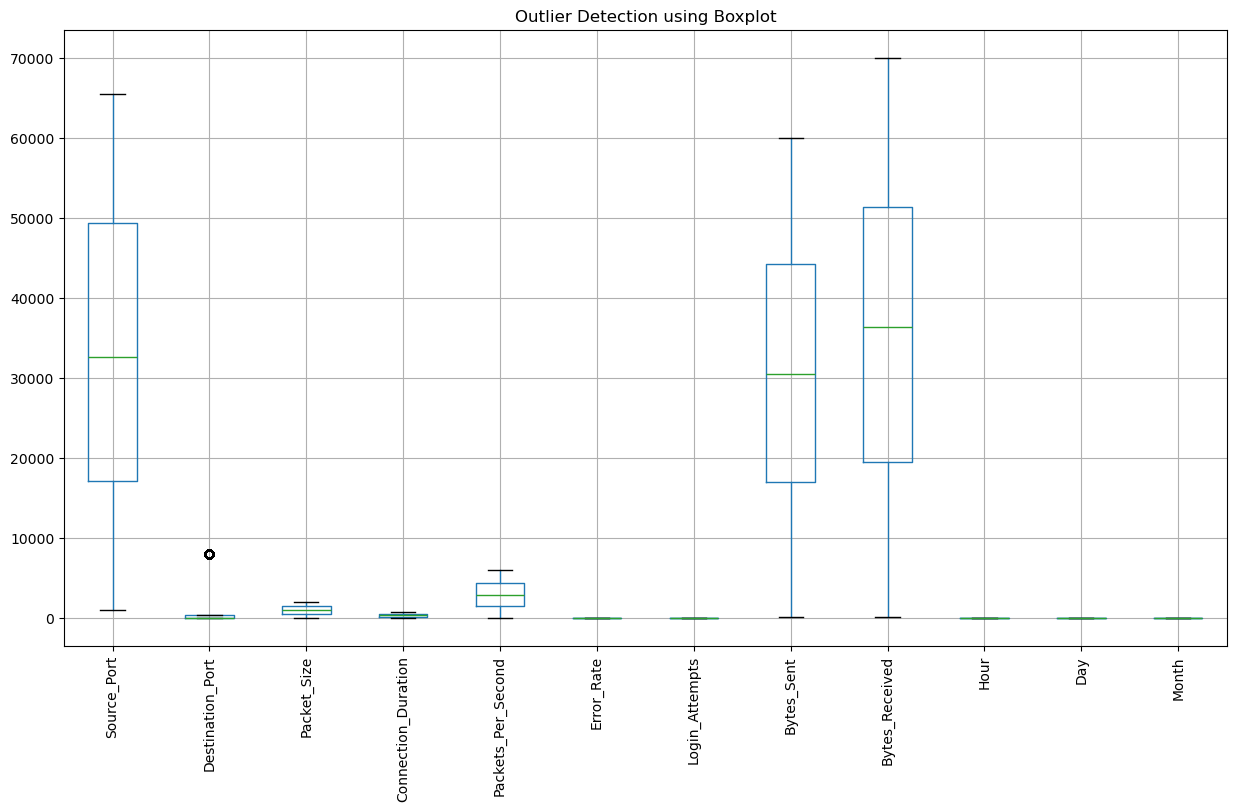

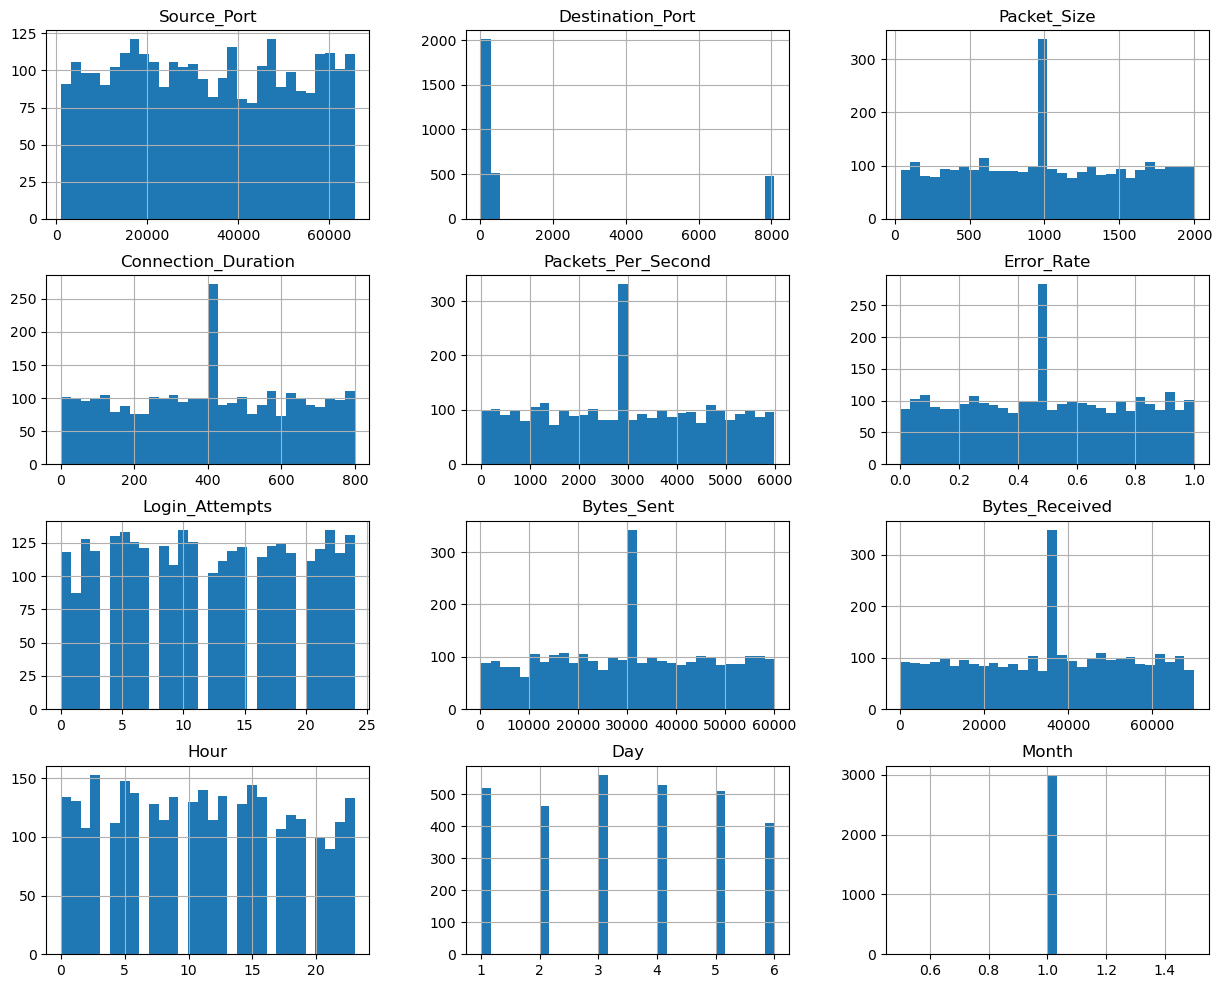

In [75]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
# remove categorical numeric columns
num_cols.remove('Protocol')
num_cols.remove('Traffic_Flag')
num_cols.remove('Label')

#boxplot visualization for outliers
plt.figure(figsize=(15,8))
df[num_cols].boxplot(rot=90)
plt.title("Outlier Detection using Boxplot")
plt.show()

#distribution visualization
df[num_cols].hist(figsize=(15,12), bins=30)
plt.show()

In [76]:
def count_outliers(df):    #to check outliers using iqr method
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        iqr = Q3 - Q1

        lower = Q1 - 1.5 * iqr
        upper = Q3 + 1.5 * iqr

        count = ((df[col] < lower) | (df[col] > upper)).sum()
        print(f"{col}: {count} outliers")

count_outliers(df)
# Outlier detection was performed using IQR method.
# No significant outliers were found, so no removal was required.
#483 outliers shown in destination port aren't outliers but a value which is larger then other values

Source_Port: 0 outliers
Destination_Port: 483 outliers
Packet_Size: 0 outliers
Connection_Duration: 0 outliers
Packets_Per_Second: 0 outliers
Error_Rate: 0 outliers
Login_Attempts: 0 outliers
Bytes_Sent: 0 outliers
Bytes_Received: 0 outliers
Hour: 0 outliers
Day: 0 outliers
Month: 0 outliers


In [77]:
# correlation matrix
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,Source_Port,Destination_Port,Protocol,Packet_Size,Connection_Duration,Packets_Per_Second,Error_Rate,Login_Attempts,Bytes_Sent,Bytes_Received,Traffic_Flag,Label,Hour,Day,Month
Source_Port,1.000000,0.006179,0.011223,0.002262,0.021235,-0.008148,-0.008274,0.019524,-0.016644,-0.033635,0.002933,-0.012325,-0.013098,0.025698,NaN
Destination_Port,0.006179,1.000000,0.013472,0.006443,0.028786,0.010768,0.007260,-0.018197,-0.023011,0.006814,-0.020677,-0.020569,-0.004581,-0.025198,NaN
Protocol,0.011223,0.013472,1.000000,-0.022750,0.020762,-0.009038,0.024471,-0.024574,-0.007629,-0.004370,0.039028,-0.036829,-0.023718,0.000635,NaN
Packet_Size,0.002262,0.006443,-0.022750,1.000000,0.029012,0.007886,-0.013378,0.015616,-0.003797,-0.028416,0.026511,0.118772,-0.013349,-0.008047,NaN
Connection_Duration,0.021235,0.028786,0.020762,0.029012,1.000000,-0.003538,-0.034536,0.020280,0.054199,0.000433,-0.012940,0.013435,-0.004274,-0.012312,NaN
Packets_Per_Second,-0.008148,0.010768,-0.009038,0.007886,-0.003538,1.000000,-0.004101,0.031531,0.021028,0.016293,0.021967,0.028975,0.020238,0.014322,NaN
Error_Rate,-0.008274,0.007260,0.024471,-0.013378,-0.034536,-0.004101,1.000000,-0.003450,-0.025291,0.000977,-0.005377,0.101898,-0.005815,0.046749,NaN
Login_Attempts,0.019524,-0.018197,-0.024574,0.015616,0.020280,0.031531,-0.003450,1.000000,-0.002071,-0.012889,0.008284,0.545247,-0.005875,0.001992,NaN
Bytes_Sent,-0.016644,-0.023011,-0.007629,-0.003797,0.054199,0.021028,-0.025291,-0.002071,1.000000,0.010928,-0.014334,0.041651,0.021668,-0.012914,NaN
Bytes_Received,-0.033635,0.006814,-0.004370,-0.028416,0.000433,0.016293,0.000977,-0.012889,0.010928,1.000000,0.005177,-0.011969,0.010689,-0.033906,NaN


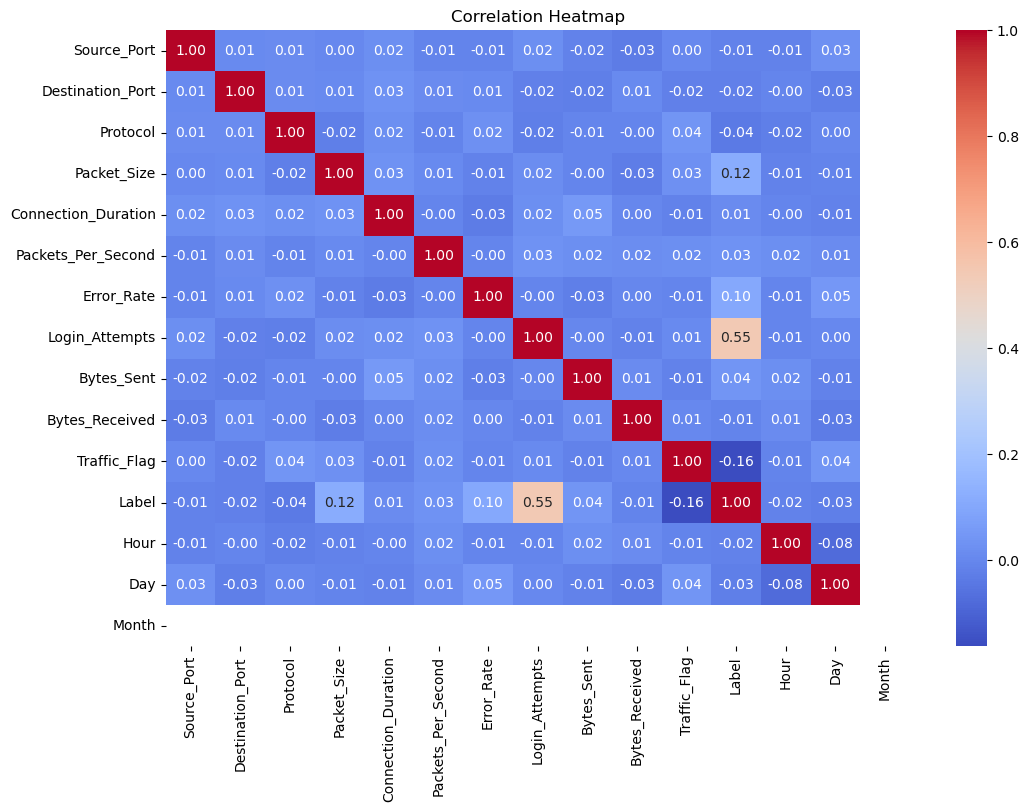

In [78]:
#visualization using heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [79]:
#removing unnecssary features from dataset
# ---- numeric correlation selection ----
corr = df.corr(numeric_only=True)["Label"]
numeric_features = corr[abs(corr) >= 0.05].index.tolist()
print("Numeric Selected:", numeric_features)
# ---- manually add important categorical feature ----
important_features = ["Connection_Duration",'Packets_Per_Second']
# combine features
selected_features = list(set(numeric_features + important_features))
print("Final Selected Features:", selected_features)

# keep only selected columns
df = df[selected_features]
print(df)

Numeric Selected: ['Packet_Size', 'Error_Rate', 'Login_Attempts', 'Traffic_Flag', 'Label']
Final Selected Features: ['Traffic_Flag', 'Label', 'Login_Attempts', 'Connection_Duration', 'Packets_Per_Second', 'Error_Rate', 'Packet_Size']
      Traffic_Flag  Label  Login_Attempts  Connection_Duration  \
0                0      1               3                334.0   
1                1      0              15                687.0   
2                2      0              12                559.0   
3                3      1              16                196.0   
4                1      1              19                777.0   
...            ...    ...             ...                  ...   
2995             1      0              16                494.0   
2996             1      0               1                463.0   
2997             1      0               8                356.0   
2998             1      0               3                208.0   
2999             3      0              1

In [81]:
cols = list(df.columns)

col_to_move = cols.pop(1)  # remove 2nd column
cols.append(col_to_move)   # add it at end

df = df[cols]

In [82]:
df.to_csv("Processed_data.csv",index=False)
#preprocessing done.